## Experiment Workflow Test
Short notebook to validate the new experiment file workflow (`experiments/podmr.py` and `experiments/rabi.py`).

In [23]:
# Adjust if your VS Code kernel needs help finding pip / scripts
import os
python_path = r"C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Scripts"
os.environ["PATH"] = python_path + ";" + os.environ["PATH"]

!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [4]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
from copy import copy
from scipy.optimize import curve_fit
import qickdawg as qd
from importlib.metadata import version

print(f"numpy     {version('numpy')}")
print(f"qickdawg  {version('qickdawg')}")
print(f"python    {sys.version}")

numpy     2.3.3
qickdawg  1.2.1
python    3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]


<a id="connect"></a>
### Connect to board

In [5]:
qd.start_client('192.168.3.1')
print("Connected — soccfg loaded:", qd.soccfg is not None)

Connected — soccfg loaded: True


In [6]:
default_config = qd.NVConfiguration()

default_config.adc_channel              = 0
default_config.mw_channel               = 0
default_config.mw_nqz                   = 1
default_config.mw_gain                  = 1800
default_config.laser_gate_pmod          = 0
default_config.laser_on_tus             = 2
default_config.laser_readout_offset_tus = 1.172
default_config.readout_integration_tns  = 300
default_config.mw_laser_delay_treg      = 0
default_config.relax_delay_tus          = 1.1
default_config.pre_init                 = True
default_config.edge_counting = True
default_config.high_threshold = 8000
default_config.low_threshold = 500

<a id="top"></a>
# Table of Contents
1. [Connect to board](#connect)
2. [Laser](#laser)
3. [Counting Duration](#cd)
3. [PODMR](#podmr)
4. [RABI](#rabi)
5. [Ramsey](#ramsey)
6. [Hahn Echo](#hahn-echo)
7. [CPMG](#cpmg)
8. [CPMG Reopt Loop](#cpmg-reopt)

<a id="laser"></a>
### Laser
[Back to top](#top)

In [9]:
# Expected: laser should illuminate the sample
qd.laser_on(copy(default_config))

0

In [10]:
# Expected: laser should turn off
qd.laser_off(copy(default_config))

0

### PL counts — live scope

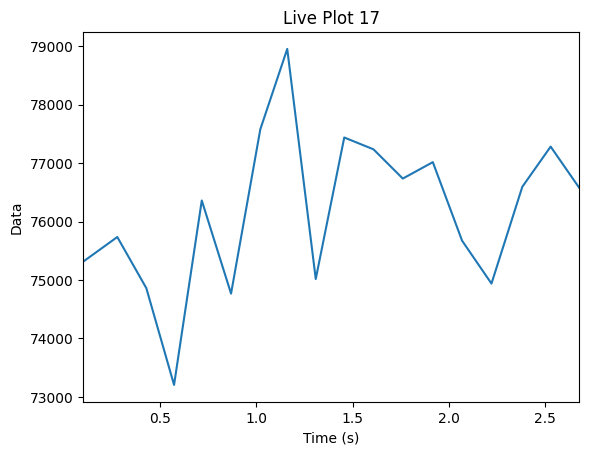

In [8]:
config = copy(default_config)
config.readout_integration_treg = 2**16 - 1
config.reps = 300
config.relax_delay_tns = 0

prog = qd.PLIntensity(config)

def get_cps():
    d = prog.acquire(progress=False)
    return d / (config.readout_integration_tus * 1e-6 * config.reps)

qd.live_plot(get_cps)

<a id="cd"></a>
### Counting Duration

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.


Counting-duration sweep:   0%|          | 0/150 [00:00<?, ?step/s]

Saved figure: c:\Users\QT3 User Facility\Documents\qick-dawg\data\counting_duration\counting_duration_full_res_20260331_162739_raw_and_subtracted.png
Saved figure: c:\Users\QT3 User Facility\Documents\qick-dawg\data\counting_duration\counting_duration_full_res_20260331_162739_snr.png


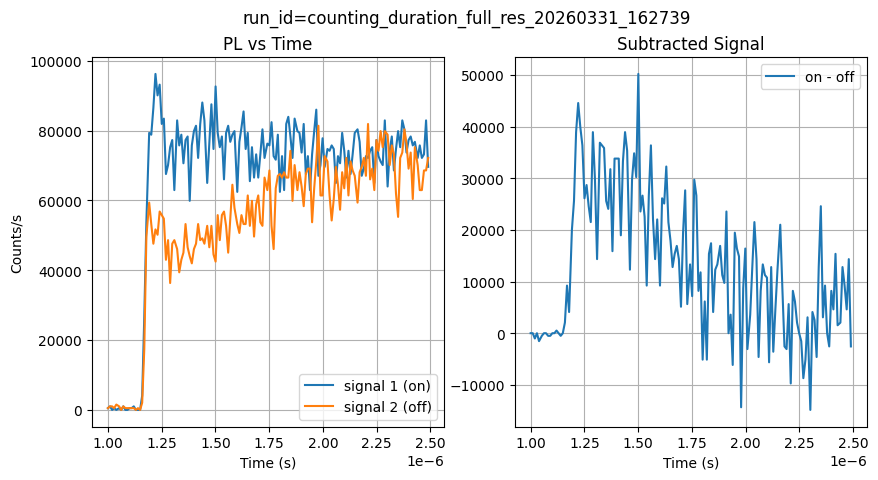

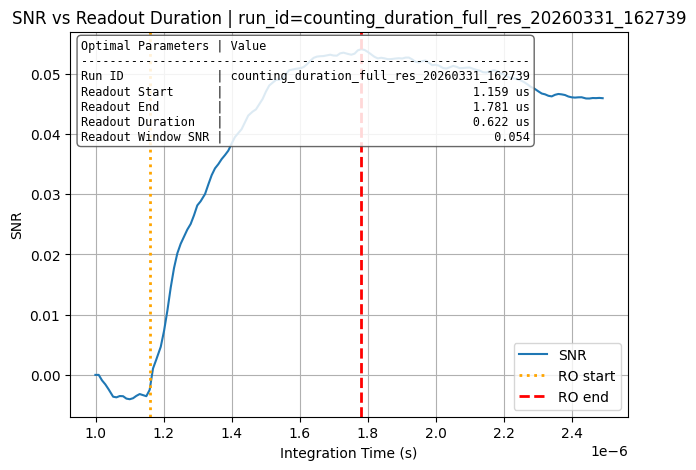

In [14]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/counting_duration.py

<a id="podmr"></a>
### PODMR
Edit parameters in `experiments/podmr.py` (EXPERIMENT PARAMETERS block), then run this cell.
The script handles connection, sweep config, acquisition, HDF5 save, and plot internally.
Use `%run -i` to inject variable overrides from a prior cell without editing the file.

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 1844.5 to 1847.5 by 0.05
Instead using 1844.4999996185302 to 1847.5000225067138 by 0.05000038146972656 in 61 steps
[podmr] Sweep: 1844.500 -> 1847.500 MHz (delta 0.050 MHz)
[podmr] Active transition: lower_dip | mw_fMHz=1845.8000003814695 MHz | mw_gain=1200
[podmr] pi pulse: OVERRIDE_MW_PI_NS=950 ns


  0%|          | 0/12200000 [00:00<?, ?it/s]

[podmr] Saved -> c:\Users\QT3 User Facility\Documents\qick-dawg\data\podmr\podmr_fine_res_20260403_183003.h5
[podmr] Contrast dip fit: center=1845.343658 MHz, depth=0.345928, width=0.438803 MHz, baseline=1.00958


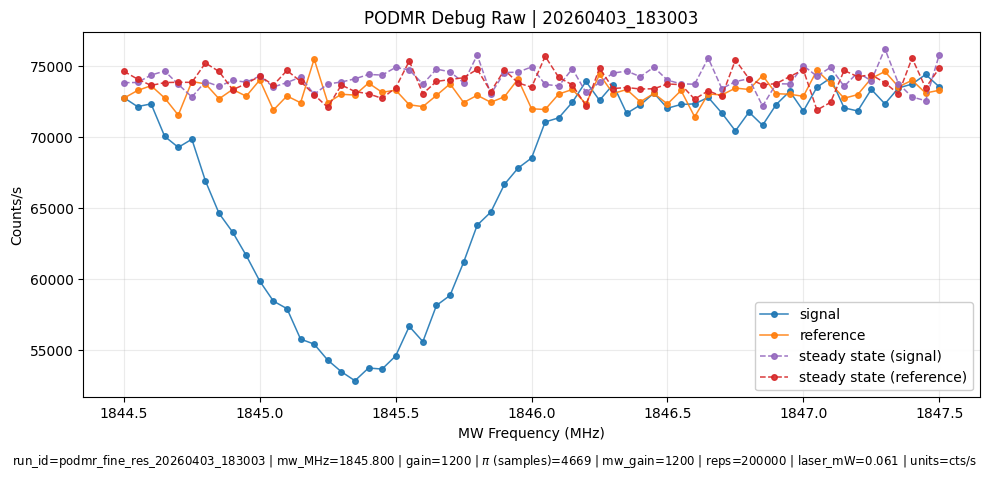

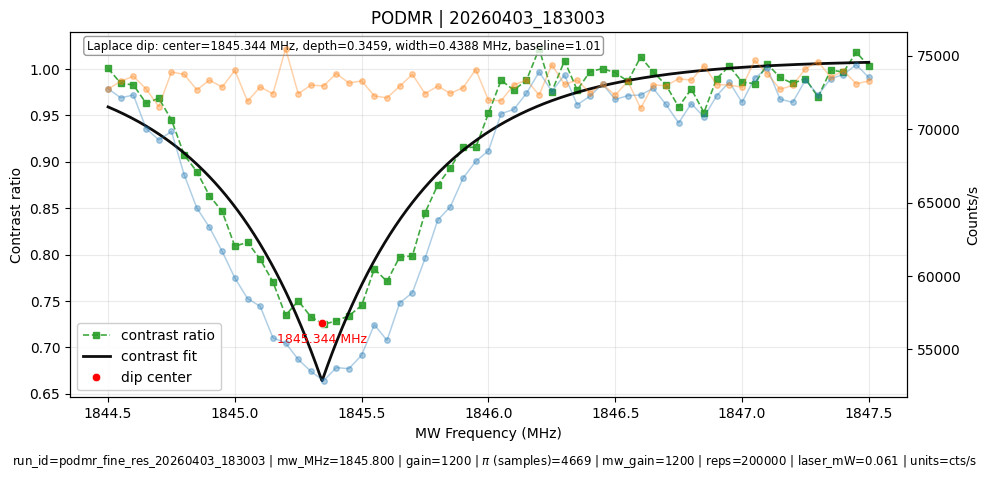

[podmr] Plot saved -> c:\Users\QT3 User Facility\Documents\qick-dawg\data\podmr\podmr_fine_res_20260403_183003.png


In [34]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/podmr.py

<a id="rabi"></a>
### RABI
Edit parameters in `experiments/rabi.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.
[rabi] Sweep: 50.000 -> 6000.000 ns (delta 50.000 ns)
[rabi] Active transition: lower_dip | freq=1845.8000003814695 MHz | gain=600

Requested 50 to 6000 by 50
Instead using 50.048828125 to 6005.859375 by 50.048828125 in 120 steps


  0%|          | 0/36000000 [00:00<?, ?it/s]

[rabi] Saved → c:\Users\QT3 User Facility\Documents\qick-dawg\data\rabi\rabi_fine_res_20260403_184905.h5
[rabi] Contrast fit (decaying): A=0.029835, T=2175.463 ns, C=0.965189, tau=6879.653 ns


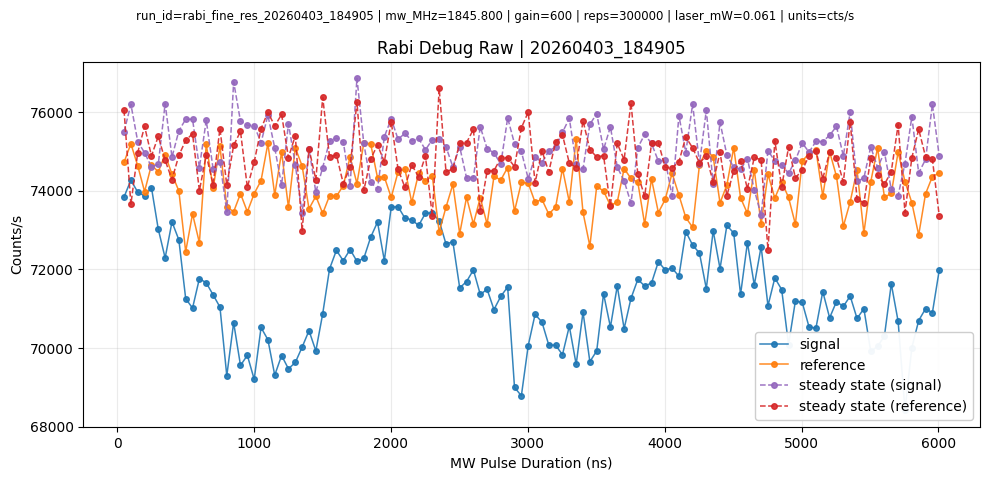

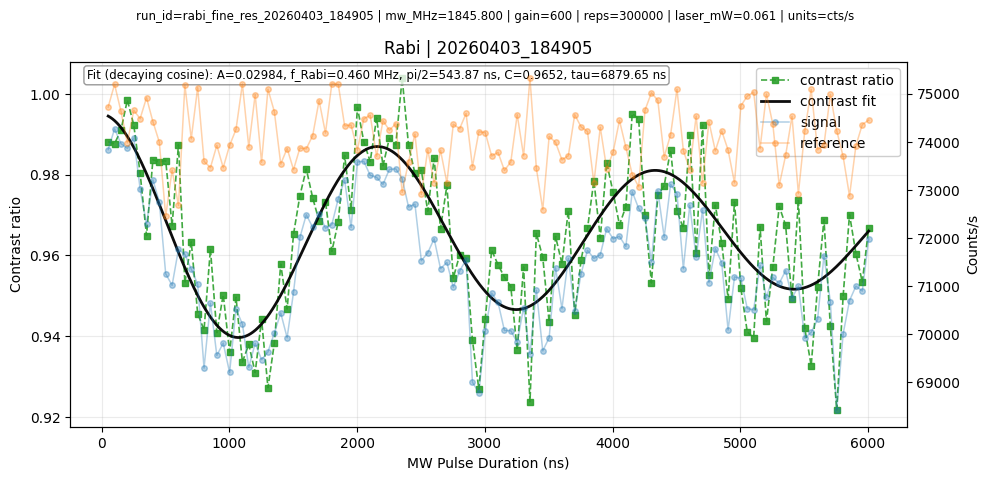

[rabi] Plot saved → c:\Users\QT3 User Facility\Documents\qick-dawg\data\rabi\rabi_fine_res_20260403_184905.png


In [40]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/rabi.py

<a id="ramsey"></a>
### Ramsey
Edit parameters in `experiments/ramsey.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 200.0 to 15000.0 by 100.0
Instead using 199.99186197916669 to 15014.444986979168 by 100.09765625 in 149 steps
[ramsey] Sweep: 199.992 -> 15014.445 ftns (linear, configured delta=100.098)
[ramsey] Active transition: lower_dip | mw_fMHz=1845.8000003814695 MHz | mw_gain=32767
[ramsey] mw_pi2_ftsamp=134, reps=80000


  0%|          | 0/11920000 [00:00<?, ?it/s]

[ramsey] Saved -> c:\Users\QT3 User Facility\Documents\qick-dawg\data\ramsey\ramsey_fine_res_20260331_172358.h5
[ramsey] Contrast fit (exp decay fallback): A=-0.207865, T2*=3.507 us, C=0.858379


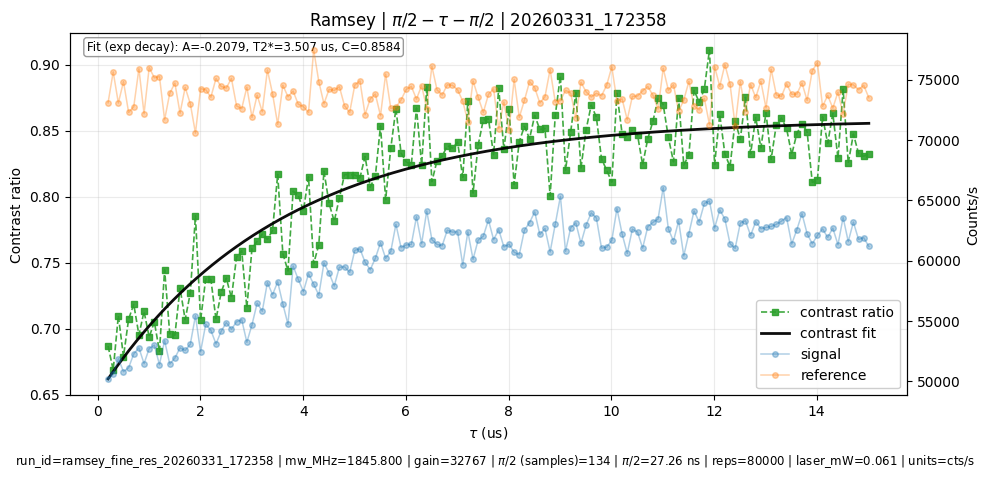

[ramsey] Plot saved -> c:\Users\QT3 User Facility\Documents\qick-dawg\data\ramsey\ramsey_fine_res_20260331_172358.png


In [47]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/ramsey.py

<a id="hahn-echo"></a>
### Hahn Echo
Edit parameters in `experiments/hahn_echo.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/hahn_echo.py

<a id="t1"></a>
### T1

[Laser](#laser) | [Top](#top)

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/t1.py

<a id="cpmg"></a>
### CPMG
Edit parameters in `experiments/cpmg.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/cpmg.py

# Miscellaneous File Reading

In [ ]:
# TODO: